# Entrenamiento de modelo de predicción de categoría


## Importación de librerias necesarias


In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2


In [2]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [3]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


2025-12-27 15:10:42.883719: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-27 15:10:42.896684: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-27 15:10:42.901063: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-27 15:10:42.910592: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-27 15:10:44.781373: W tensorflow/compiler/tf2

In [4]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.14 (main, Oct 10 2025, 08:54:04) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: []
❌ No GPU detected


I0000 00:00:1766866249.360368  342225 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-27 15:10:49.406302: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark

:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-723f41c6-13c0-4667-a2ac-d76da6f4cfe5;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 101ms :: artifacts dl 4ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

## Cargar datos fuente de entrenamiento


In [6]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [7]:
REGENERATE_MODEL = True


In [8]:
src_dir_category_prediction = spark_utils.path(
    'final_training_data_category_prediction', catalog = GOLD_PREMODELING
)

In [9]:
categories = spark.read.parquet(src_dir_category_prediction).schema.names
categories = [bytes(c, 'utf-8') for c in categories if c.startswith("main_category_")]

In [10]:
TRACKING_URI = "file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow"

In [11]:
from src.utils.models import CategoryPredictionModel
category_prediction_model = CategoryPredictionModel(
    'category_prediction_model', 
    METASTORE_PATH, 
    num_classes=len(categories),
    tracking_uri=TRACKING_URI,
    spark_utils=spark_utils,
    target_path=src_dir_category_prediction,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)
category_prediction_model.prepare_data(
    target_columns=categories, 
    shuffle_buffer_size=-1,
    batch_size=128,
)

2025-12-27 15:11:01.455273: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


## Crear modelo de predicción


In [12]:
category_prediction_model.create_model()
category_prediction_model.model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │       154,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 861,961 (3.29 MB)

 Trainable params: 858,121 (3.27 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [13]:
category_prediction_model.plot_model(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/category_prediction_model.png",
    levels = 5
)

{'attributes': {'rankdir': 'LR', 'concentrate': True, 'dpi': 200, 'splines': 'ortho'}, 'name': '', 'type': 'digraph', 'strict': False, 'suppress_disconnected': False, 'simplify': False, 'current_child_sequence': 38, 'nodes': {'node': [{'attributes': {'shape': 'record'}, 'type': 'node', 'parent_graph': <pydot.core.Dot object at 0x7ed59c160b90>, 'sequence': 1, 'name': 'node', 'port': None}, {'attributes': {'style': 'filled', 'fillcolor': '#ffffff', 'fontcolor': '#000000', 'fontname': 'Times New Roman', 'fontsize': '12', 'color': '#ffffff', 'penwidth': '1.0'}, 'type': 'node', 'parent_graph': <pydot.core.Dot object at 0x7ed59c160b90>, 'sequence': 32, 'name': 'node', 'port': None}], '139455691206544': [{'attributes': {'label': '<<table border="0" cellborder="1" bgcolor="#193169" cellpadding="10"><tr><td colspan="2" bgcolor="#193169"><font point-size="16" color="white"><b>dense</b> (Dense)</font></td></tr><tr><td bgcolor="white"><font point-size="14">Input shape: <b>(None, 150)</b></font></t

'/mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_prediction_model.png'

In [15]:
if REGENERATE_MODEL:
    history_model_category_prediction = category_prediction_model.train(epochs=50)

Epoch 1/50
    401/Unknown 17s 24ms/step - accuracy: 0.4655 - loss: 1.6252

2025-11-15 22:29:18.551715: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.62102, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_prediction_model/model_checkpoints/rating_model_epoch_01.h5


2025-11-15 22:29:27.874861: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


404/404 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - accuracy: 0.5615 - loss: 1.3615 - val_accuracy: 0.6210 - val_loss: 1.2959 - learning_rate: 0.0010
Epoch 2/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6530 - loss: 1.1106
Epoch 2: val_accuracy improved from 0.62102 to 0.70411, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_prediction_model/model_checkpoints/rating_model_epoch_02.h5


...

400/404 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8072 - loss: 0.6283
Epoch 9: val_accuracy did not improve from 0.72473
404/404 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8131 - loss: 0.6086 - val_accuracy: 0.7176 - val_loss: 1.0071 - learning_rate: 0.0010
Epoch 10/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8237 - loss: 0.5771
Epoch 10: val_accuracy did not improve from 0.72473
404/404 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8278 - loss: 0.5600 - val_accuracy: 0.7201 - val_loss: 1.0559 - learning_rate: 0.0010
Epoch 11/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8385 - loss: 0.5288
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 11: val_accuracy did not improve from 0.72473
404/404 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8409 - loss: 0.5171 - val_accuracy: 0.7044 - val_loss: 1.0980 - learning_rate: 0.0010
Epoch 12/50
401/404 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8577 - loss: 0.460

404/404 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.8749 - loss: 0.4058 - val_accuracy: 0.7269 - val_loss: 1.1781 - learning_rate: 3.0000e-04
Epoch 13/50
400/404 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8894 - loss: 0.3598
Epoch 13: val_accuracy did not improve from 0.72688
404/404 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8970 - loss: 0.3344 - val_accuracy: 0.7236 - val_loss: 1.2712 - learning_rate: 3.0000e-04
Epoch 14/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9057 - loss: 0.3099
Epoch 14: val_accuracy did not improve from 0.72688
404/404 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9119 - loss: 0.2870 - val_accuracy: 0.7250 - val_loss: 1.3565 - learning_rate: 3.0000e-04
Epoch 15/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9158 - loss: 0.2751
Epoch 15: val_accuracy did not improve from 0.72688
404/404 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9213 - loss: 0.2593 - val_accuracy: 0.7210 - val_loss: 1.4586 - learning_rate: 3.0

2025-11-15 22:33:24.344599: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9334 - loss: 0.2188
Epoch 17: val_accuracy did not improve from 0.72688
404/404 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9360 - loss: 0.2079 - val_accuracy: 0.7200 - val_loss: 1.6412 - learning_rate: 3.0000e-04
Epoch 18/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9357 - loss: 0.2085
Epoch 18: val_accuracy did not improve from 0.72688
404/404 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9401 - loss: 0.1948 - val_accuracy: 0.7161 - val_loss: 1.6734 - learning_rate: 3.0000e-04
Epoch 19/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9440 - loss: 0.1824
Epoch 19: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 19: val_accuracy did not improve from 0.72688
404/404 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9456 - loss: 0.1747 - val_accuracy: 0.7201 - val_loss: 1.7757 - learning_rate: 3.0000e-04
Epoch 20/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9478 

2025-11-15 22:37:35.524137: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


2025/11/15 22:44:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/15 22:44:32 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/11/15 22:46:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Experimento 349f09dd94a643c090f2c11fbc2c6889
6475 6475
Confusion matrix saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_prediction_model/confusion_matrix.png
Error logging confusion matrix to MLflow: Could not find experiment with ID 0


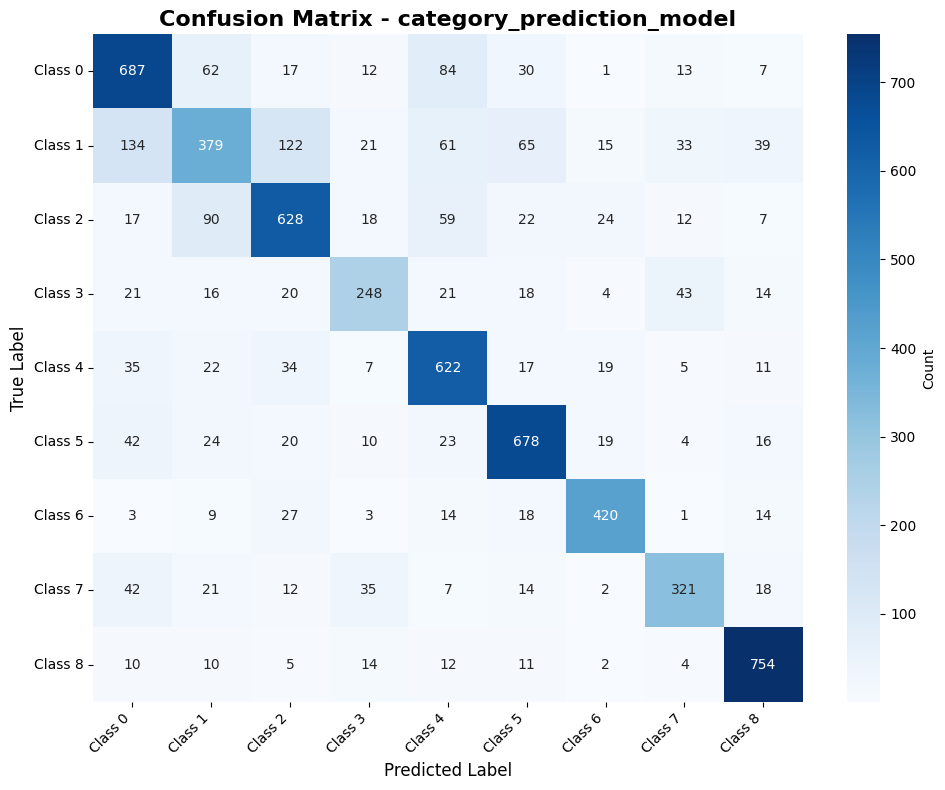

Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_category_prediction_category_prediction_model.png


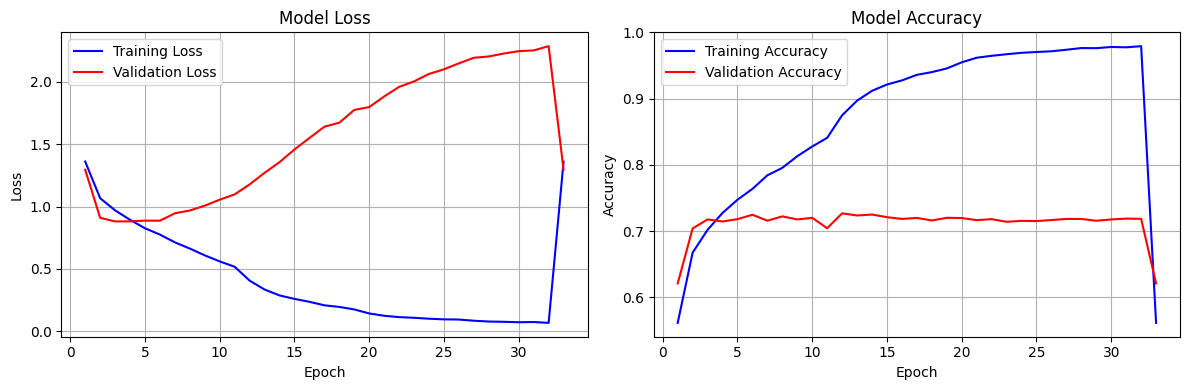

In [ ]:
if REGENERATE_MODEL:
    for name, model in [
        ("category_prediction_model", category_prediction_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print("Experimento", exp)
        

        category_prediction_model.plot_confusion_matrix()

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_category_prediction_{name}.png"
        )


## Cargar modelo


In [12]:
from src.utils.models import CategoryPredictionModel
category_prediction_model = CategoryPredictionModel(
    'category_prediction_model', 
    METASTORE_PATH, 
    num_classes=len(categories),
    tracking_uri=TRACKING_URI,
    spark_utils=spark_utils,
    target_path=src_dir_category_prediction,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)
# category_prediction_model.prepare_data(
#     target_columns=categories, 
#     shuffle_buffer_size=-1,
#     batch_size=128,
# )
category_prediction_model.load_latest_model()

/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 24 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [25]:
categories

[b'main_category_computers',
 b'main_category_all_electronics',
 b'main_category_home_audio_theater',
 b'main_category_amazon_home',
 b'main_category_industrial_scientific',
 b'main_category_cell_phones_accessories',
 b'main_category_car_electronics',
 b'main_category_office_products',
 b'main_category_camera_photo']

Using cached evaluation results
Confusion matrix saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_prediction_model/confusion_matrix.png
Error logging confusion matrix to MLflow: Could not find experiment with ID 0


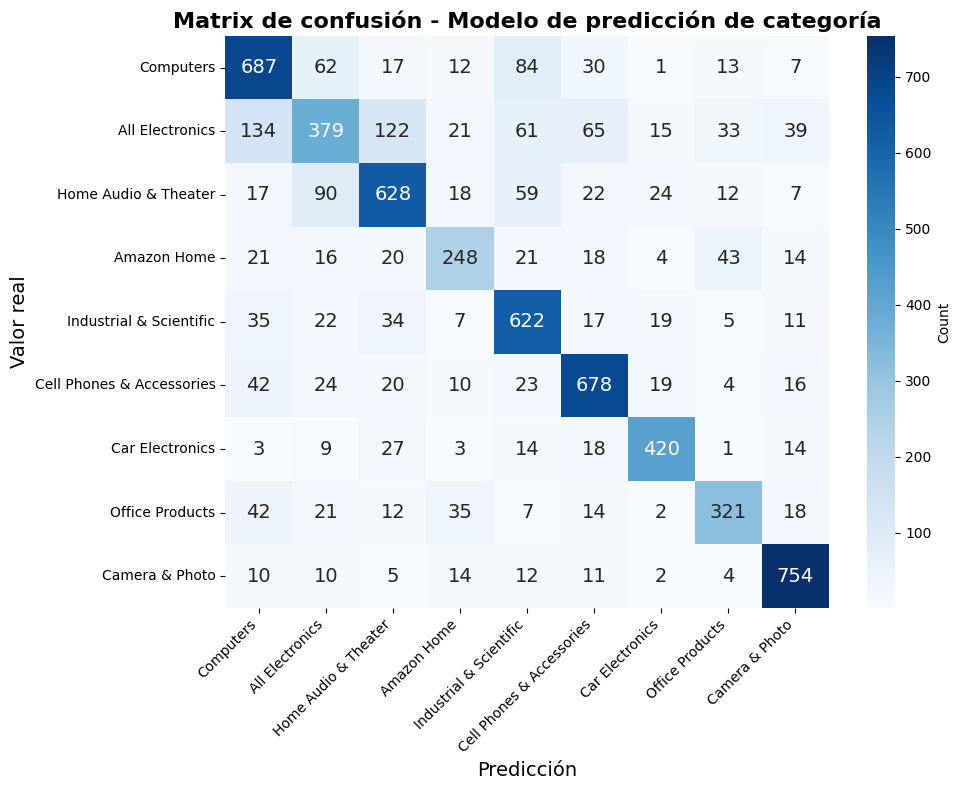

array([[687,  62,  17,  12,  84,  30,   1,  13,   7],
       [134, 379, 122,  21,  61,  65,  15,  33,  39],
       [ 17,  90, 628,  18,  59,  22,  24,  12,   7],
       [ 21,  16,  20, 248,  21,  18,   4,  43,  14],
       [ 35,  22,  34,   7, 622,  17,  19,   5,  11],
       [ 42,  24,  20,  10,  23, 678,  19,   4,  16],
       [  3,   9,  27,   3,  14,  18, 420,   1,  14],
       [ 42,  21,  12,  35,   7,  14,   2, 321,  18],
       [ 10,  10,   5,  14,  12,  11,   2,   4, 754]])

In [27]:
category_prediction_model.plot_confusion_matrix(
    title = 'Matrix de confusión - Modelo de predicción de categoría',
    class_names = [
        'Computers',
        'All Electronics',
        'Home Audio & Theater',
        'Amazon Home',
        'Industrial & Scientific',
        'Cell Phones & Accessories',
        'Car Electronics',
        'Office Products',
        'Camera & Photo'
    ],
    xlabel = 'Predicción',
    ylabel = 'Valor real',
    annot_fontsize = 14,
    label_fontsize = 14,
)

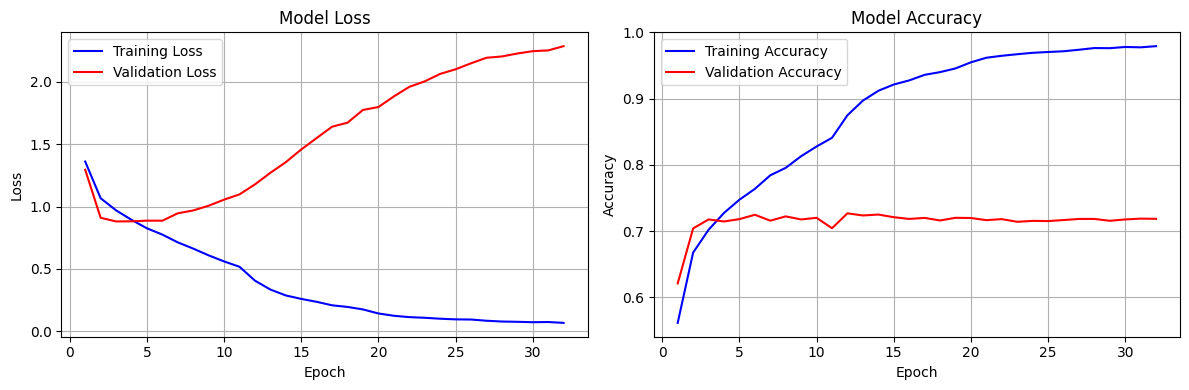

In [28]:
category_prediction_model.plot_latest_model_history()

In [ ]:


categories = spark.read.parquet(src_dir_category_prediction).schema.names
categories = [bytes(c, 'utf-8') for c in categories if c.startswith("main_category_")]

category_prediction_model = CategoryPredictionModel('category_prediction_model', METASTORE_PATH, num_classes=len(categories), tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")



/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 24 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [14]:
from src.utils.models import CategoryPredictionModel
category_prediction_model = CategoryPredictionModel(
    'category_prediction_model', 
    METASTORE_PATH, 
    num_classes=len(categories),
    tracking_uri=TRACKING_URI,
    spark_utils=spark_utils,
    target_path=src_dir_category_prediction,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)
category_prediction_model.input_shape = 150
category_prediction_model.create_model()
category_prediction_model.model.summary()
category_prediction_model.plot_model(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/category_prediction_model.png",
    levels = 4
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 1024)           │       154,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 861,961 (3.29 MB)

 Trainable params: 858,121 (3.27 MB)

 Non-trainable params: 3,840 (15.00 KB)

model plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_prediction_model.png


'/mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_prediction_model.png'